In [2]:
# -------------------- Section 1: Dataset Description --------------------

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('creditcard.csv')

# Dataset overview
total_rows, total_cols = df.shape

# Feature description table
feature_df = pd.DataFrame({
    'Feature': ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class'],
    'Type': ['Numerical (Continuous)'] * 30 + ['Categorical (Binary)'],
    'Description': [
        'Seconds elapsed between this and the first transaction',
        *[f'PCA Component {i} (anonymized feature)' for i in range(1, 29)],
        'Transaction amount in Euros',
        'Target variable: 1 = Fraud, 0 = Normal'
    ],
    'Classification': ['Numerical - Continuous'] * 30 + ['Categorical - Binary']
})

# Display summary info
dataset_summary = {
    'Total Rows': total_rows,
    'Total Columns': total_cols,
    'Source': 'Kaggle - MLG-ULB (Universite Libre de Bruxelles)',
    'Real-world Problem': 'Detecting fraudulent credit card transactions',
    'Time Period': 'September 2013, 2 days, European cardholders'
}

print("=== Dataset Summary ===")
for k, v in dataset_summary.items():
    print(f"{k}: {v}")

print("\nFeature Description Table:")
print(feature_df)

print("\n✅ Section 1 done successfully!")


=== Dataset Summary ===
Total Rows: 284807
Total Columns: 31
Source: Kaggle - MLG-ULB (Universite Libre de Bruxelles)
Real-world Problem: Detecting fraudulent credit card transactions
Time Period: September 2013, 2 days, European cardholders

Feature Description Table:
   Feature                    Type  \
0     Time  Numerical (Continuous)   
1       V1  Numerical (Continuous)   
2       V2  Numerical (Continuous)   
3       V3  Numerical (Continuous)   
4       V4  Numerical (Continuous)   
5       V5  Numerical (Continuous)   
6       V6  Numerical (Continuous)   
7       V7  Numerical (Continuous)   
8       V8  Numerical (Continuous)   
9       V9  Numerical (Continuous)   
10     V10  Numerical (Continuous)   
11     V11  Numerical (Continuous)   
12     V12  Numerical (Continuous)   
13     V13  Numerical (Continuous)   
14     V14  Numerical (Continuous)   
15     V15  Numerical (Continuous)   
16     V16  Numerical (Continuous)   
17     V17  Numerical (Continuous)   
18     V

In [3]:
# ------------------- Section 2: Central Tendency & Dispersion -------------------

import pandas as pd

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Central tendency
mean_values   = df[numeric_cols].mean()
median_values = df[numeric_cols].median()
mode_values   = df[numeric_cols].mode().iloc[0]

# Dispersion
variance_values = df[numeric_cols].var()
std_values      = df[numeric_cols].std()
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Skewness (mean vs median)
skewness_dict = {}
for col in numeric_cols:
    if mean_values[col] > median_values[col]:
        skewness_dict[col] = 'Right-skewed'
    elif mean_values[col] < median_values[col]:
        skewness_dict[col] = 'Left-skewed'
    else:
        skewness_dict[col] = 'Symmetric'

skewness_series = pd.Series(skewness_dict)

# Outlier count using IQR
outlier_counts = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | 
                  (df[numeric_cols] > (Q3 + 1.5*IQR))).sum()

# Combine all in one DataFrame
table_stats = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Mode': mode_values,
    'Variance': variance_values,
    'Std Dev': std_values,
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Skewness': skewness_series,
    'Outlier Count': outlier_counts
}).round(2)

# Display the table
print("=== Central Tendency & Dispersion Summary ===")
display(table_stats)  # works in Jupyter; in plain Python use print(table_stats)

print("\n✅ Section 2 done successfully!")

=== Central Tendency & Dispersion Summary ===


,Mean,Median,Mode,Variance,Std Dev,Q1,Q3,IQR,Skewness,Outlier Count
Time,94813.86,84692.00,163152.00,2.255124e+09,47488.15,54201.50,139320.50,85119.00,Right-skewed,0
V1,0.00,0.02,1.25,3.840000e+00,1.96,-0.92,1.32,2.24,Left-skewed,7062
V2,0.00,0.07,-0.33,2.730000e+00,1.65,-0.60,0.80,1.40,Left-skewed,13526
V3,-0.00,0.18,-2.75,2.300000e+00,1.52,-0.89,1.03,1.92,Left-skewed,3363
V4,0.00,-0.02,-0.84,2.000000e+00,1.42,-0.85,0.74,1.59,Right-skewed,11148
V5,0.00,-0.05,-0.56,1.910000e+00,1.38,-0.69,0.61,1.30,Right-skewed,12295
V6,0.00,-0.27,-1.01,1.770000e+00,1.33,-0.77,0.40,1.17,Right-skewed,22965
V7,-0.00,0.04,-0.43,1.530000e+00,1.24,-0.55,0.57,1.12,Left-skewed,8948
V8,0.00,0.02,-0.16,1.430000e+00,1.19,-0.21,0.33,0.54,Left-skewed,24134
V9,-0.00,-0.05,0.17,1.210000e+00,1.10,-0.64,0.60,1.24,Right-skewed,8283



✅ Section 2 done successfully!


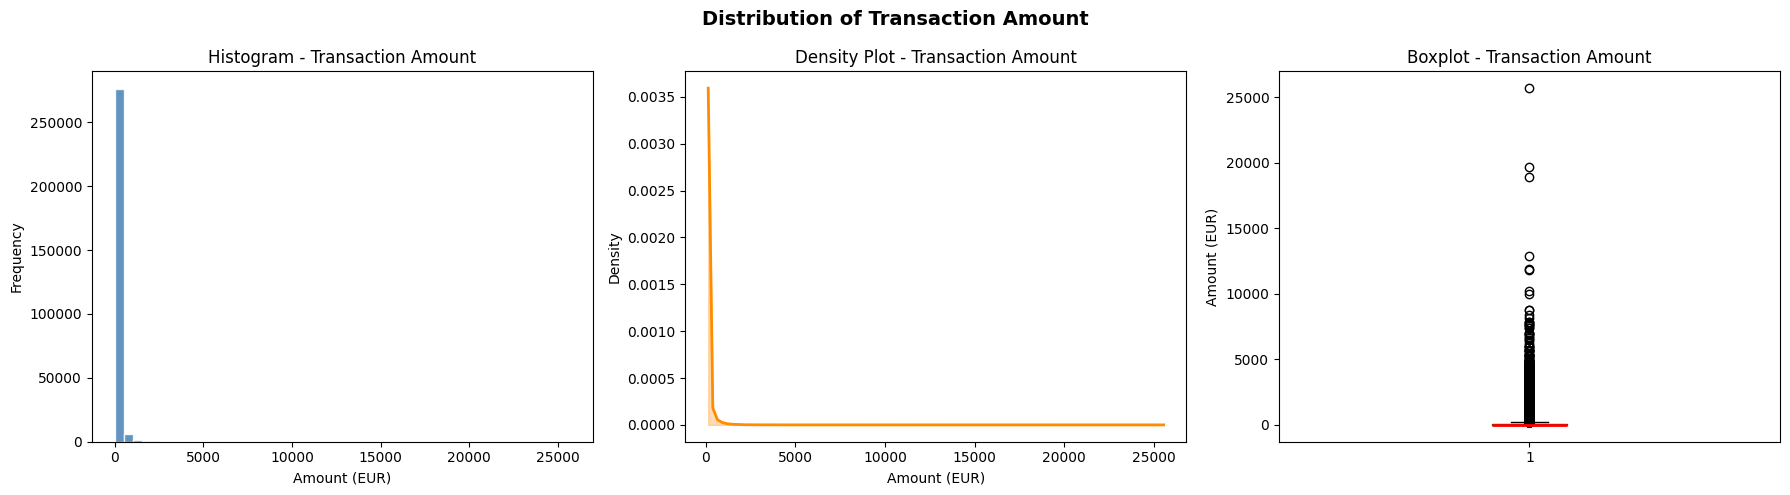

Skewness of Amount: 16.9777
=> Highly right-skewed: Most transactions are small; a few are very large.
Section 3.1 done successfully


In [4]:
# ------------------------
# 3.1 Distribution of Transaction Amount
# ------------------------

import matplotlib.pyplot as plt
import numpy as np

# Reduce bins for performance on low-spec laptop
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogram - Transaction Amount')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Frequency')

# Density Plot using numpy
counts, bin_edges = np.histogram(df['Amount'].values, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
axes[1].plot(bin_centers, counts, color='darkorange', linewidth=2)
axes[1].fill_between(bin_centers, counts, alpha=0.3, color='darkorange')
axes[1].set_title('Density Plot - Transaction Amount')
axes[1].set_xlabel('Amount (EUR)')
axes[1].set_ylabel('Density')

# Boxplot
axes[2].boxplot(df['Amount'], patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Boxplot - Transaction Amount')
axes[2].set_ylabel('Amount (EUR)')

plt.suptitle('Distribution of Transaction Amount', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness of Amount: {df['Amount'].skew():.4f}")
print('=> Highly right-skewed: Most transactions are small; a few are very large.')
print('Section 3.1 done successfully')

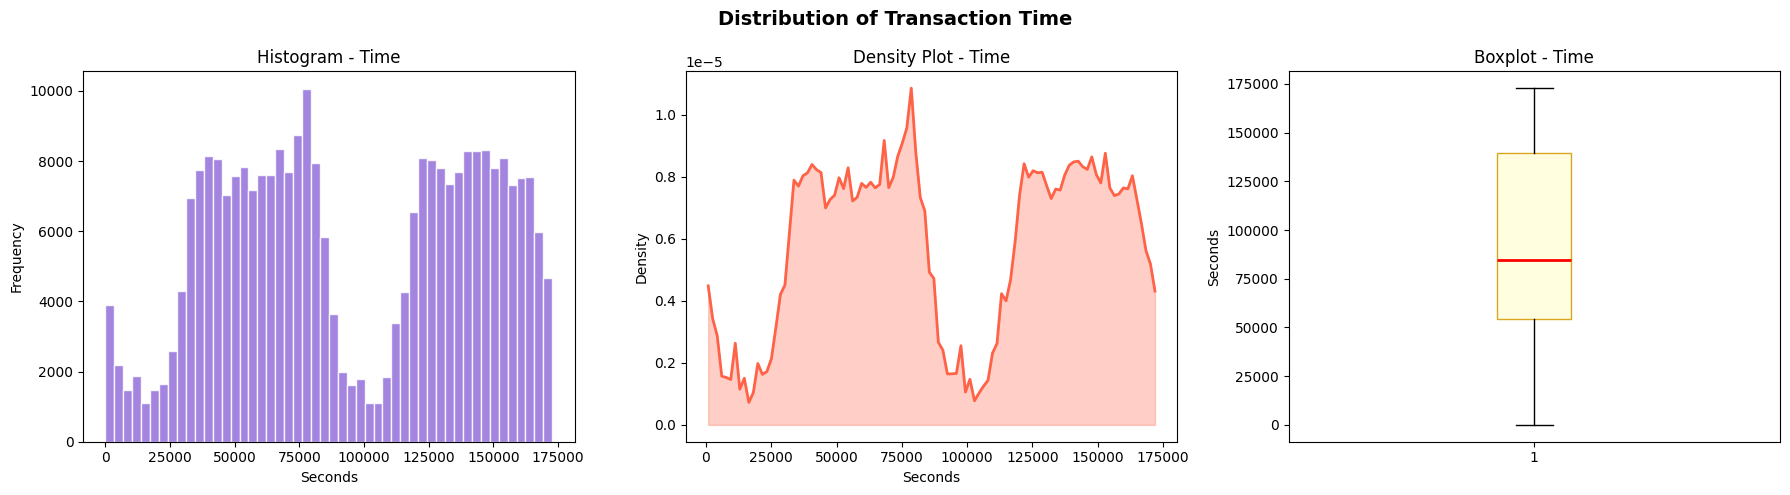

Skewness of Time: -0.0356
=> Bimodal distribution: Two peaks suggest day and night transaction patterns.
Section 3.2 done successfully


In [5]:
# ------------------------
# 3.2 Distribution of Transaction Time
# ------------------------

# Reduce bins for performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['Time'], bins=50, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogram - Time')
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Frequency')

# Density Plot
counts_t, be_t = np.histogram(df['Time'].values, bins=100, density=True)
bc_t = (be_t[:-1] + be_t[1:]) / 2
axes[1].plot(bc_t, counts_t, color='tomato', linewidth=2)
axes[1].fill_between(bc_t, counts_t, alpha=0.3, color='tomato')
axes[1].set_title('Density Plot - Time')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Density')

# Boxplot
axes[2].boxplot(df['Time'], patch_artist=True,
                boxprops=dict(facecolor='lightyellow', color='goldenrod'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Boxplot - Time')
axes[2].set_ylabel('Seconds')

plt.suptitle('Distribution of Transaction Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness of Time: {df['Time'].skew():.4f}")
print('=> Bimodal distribution: Two peaks suggest day and night transaction patterns.')
print('Section 3.2 done successfully')

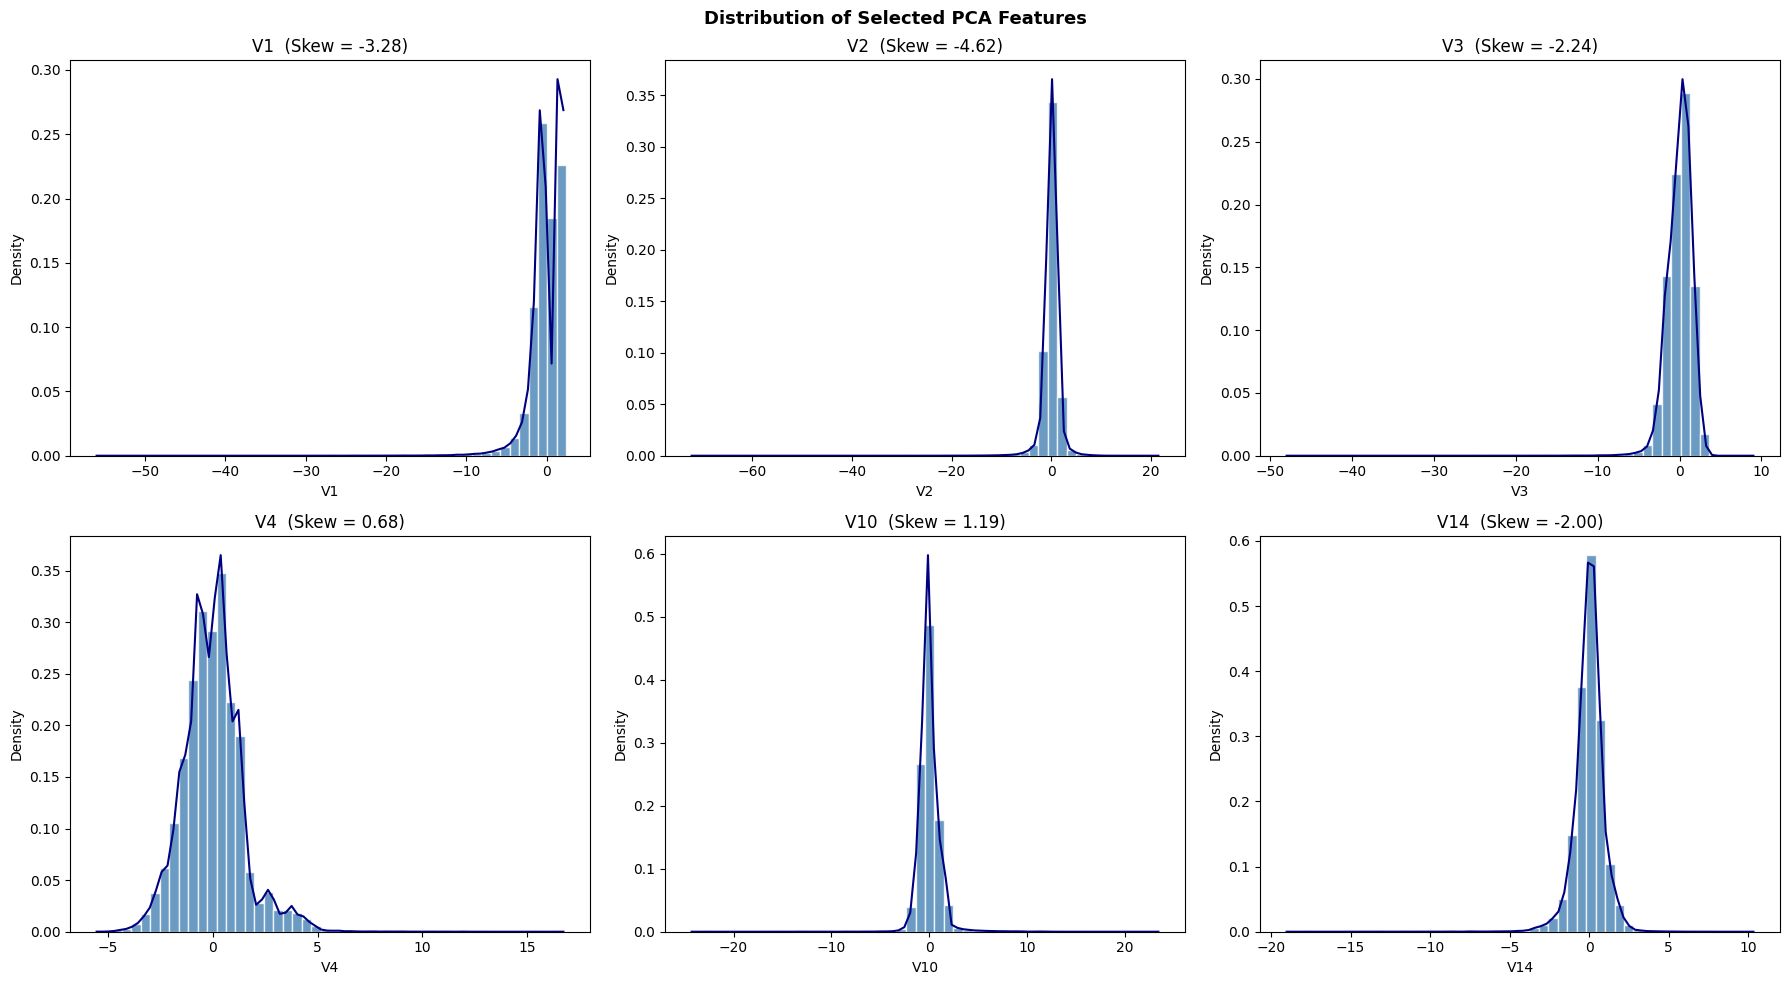

Section 3.3 done successfully


In [6]:
# ------------------------
# 3.3 Distribution of Selected PCA Features
# ------------------------

# Select a subset of V features for plotting
selected_v = ['V1', 'V2', 'V3', 'V4', 'V10', 'V14']

# Setup subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(selected_v):
    # Histogram with reduced bins
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    
    # Density line
    c, be = np.histogram(df[col].values, bins=80, density=True)
    bc = (be[:-1] + be[1:]) / 2
    axes[i].plot(bc, c, color='navy', linewidth=1.5)
    
    axes[i].set_title(f'{col}  (Skew = {df[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.suptitle('Distribution of Selected PCA Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Section 3.3 done successfully')

In [7]:
# --- 3.4 Outlier Detection using IQR Rule ---
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('creditcard.csv')

print(f"Shape: {df.shape}")
outlier_rows = []
for col in ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'Feature'     : col,
        'Lower Bound' : round(lower, 2),
        'Upper Bound' : round(upper, 2),
        'Num Outliers': n_out,
        'Outlier %'   : round(100 * n_out / len(df), 2)
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('Outlier %', ascending=False)
print('Outlier Summary (IQR Rule):')
outlier_df


Shape: (284807, 31)
Outlier Summary (IQR Rule):


,Feature,Lower Bound,Upper Bound,Num Outliers,Outlier %
28,V27,-0.31,0.33,39163,13.75
1,Amount,-101.75,184.51,31904,11.20
29,V28,-0.25,0.28,30342,10.65
21,V20,-0.73,0.65,27770,9.75
9,V8,-1.01,1.13,24134,8.47
7,V6,-2.52,2.15,22965,8.06
24,V23,-0.63,0.61,18541,6.51
13,V12,-1.94,2.15,15348,5.39
22,V21,-0.85,0.81,14497,5.09
15,V14,-1.80,1.87,14149,4.97


In [8]:
# section 4.1 class frequency table
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

class_table = pd.DataFrame({
    'Class Label'   : ['Normal (0)', 'Fraud (1)'],
    'Count'         : [class_counts[0], class_counts[1]],
    'Percentage (%)': [round(class_pct[0], 4), round(class_pct[1], 4)]
})
print('Class Frequency Table:')
class_table

Class Frequency Table:


,Class Label,Count,Percentage (%)
0,Normal (0),284315,99.8273
1,Fraud (1),492,0.1727


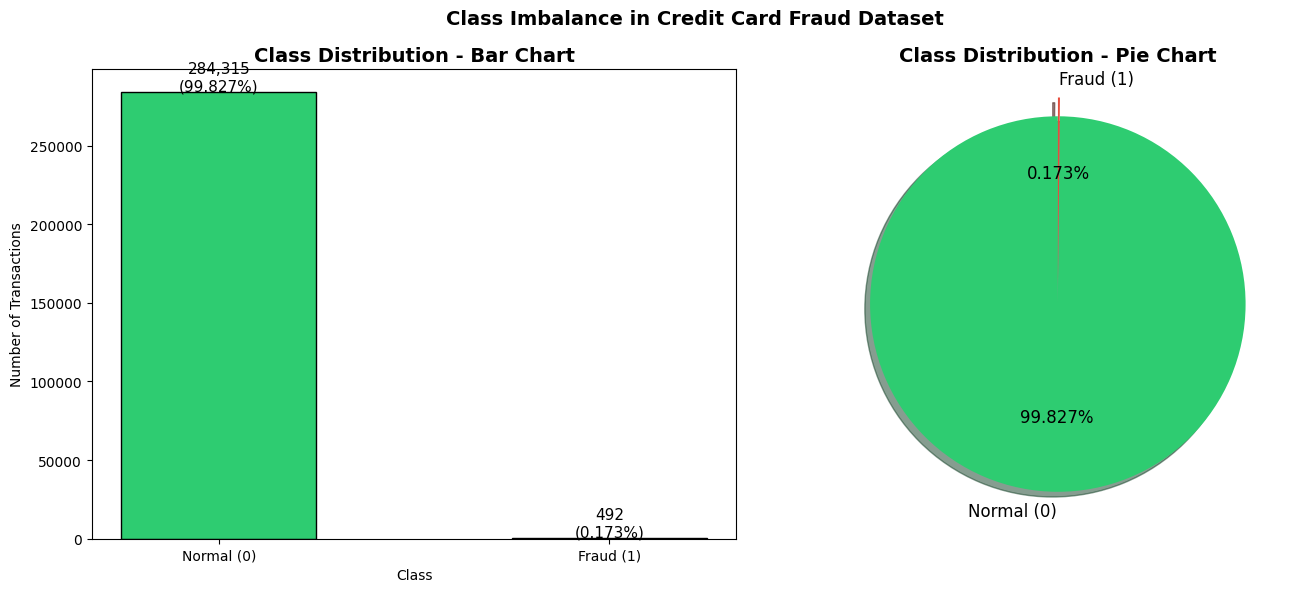

Observation: Only 0.172% of transactions are fraudulent — severe class imbalance!


In [9]:

# Section: 4.2 Class Distribution Plots
# ------------------------

# Import libraries (if not already imported)
import matplotlib.pyplot as plt
import pandas as pd

# Make sure df exists and class counts are computed
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels = ['Normal (0)', 'Fraud (1)']
values = [class_counts[0], class_counts[1]]
colors = ['#2ecc71', '#e74c3c']

# Bar Chart
bars = axes[0].bar(labels, values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Class')
for bar, val, pct in zip(bars, values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1000,
                 f'{val:,}\n({pct:.3f}%)', ha='center', fontsize=11)

# Pie Chart
axes[1].pie(values, labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90, explode=(0, 0.1),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance in Credit Card Fraud Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: Only 0.172% of transactions are fraudulent — severe class imbalance!')

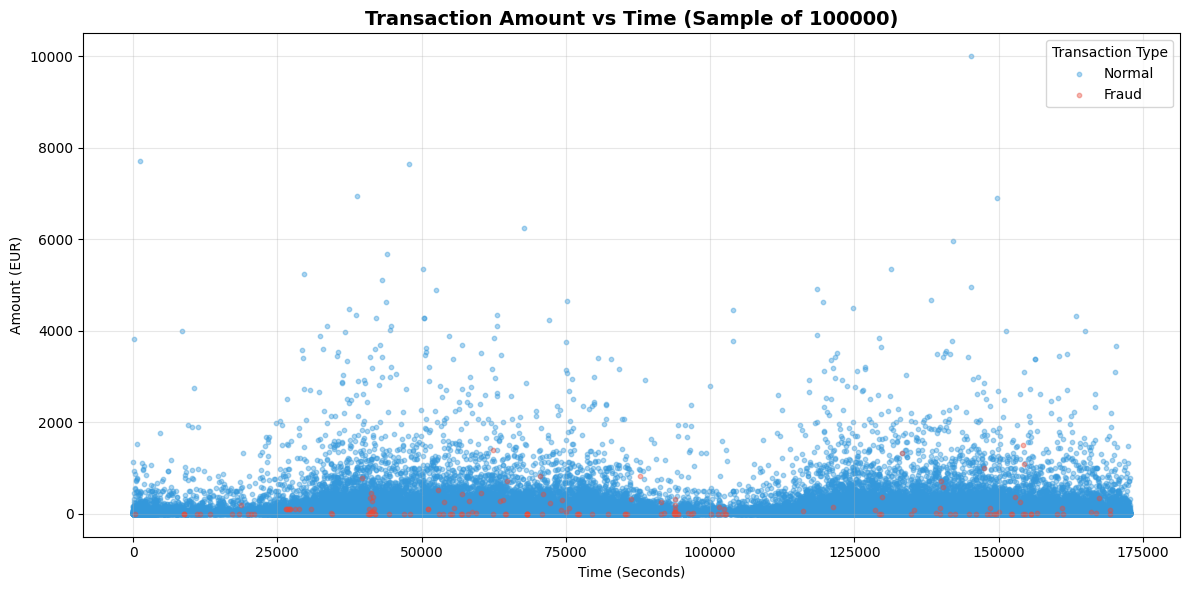

In [10]:
# --- 5.1 Amount vs Time Scatterplot ---

import matplotlib.pyplot as plt  
import pandas as pd

# Use sample for performance
sample_df = df.sample(100000, random_state=42)

plt.figure(figsize=(12, 6))

# Scatter plot colored by Class
for cls, label, color in zip([0, 1], ['Normal', 'Fraud'], ['#3498db', '#e74c3c']):
    sub = sample_df[sample_df['Class'] == cls]
    plt.scatter(sub['Time'], sub['Amount'], alpha=0.4, label=label, color=color, s=10)

plt.title('Transaction Amount vs Time (Sample of 100000)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amount (EUR)')
plt.legend(title='Transaction Type')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


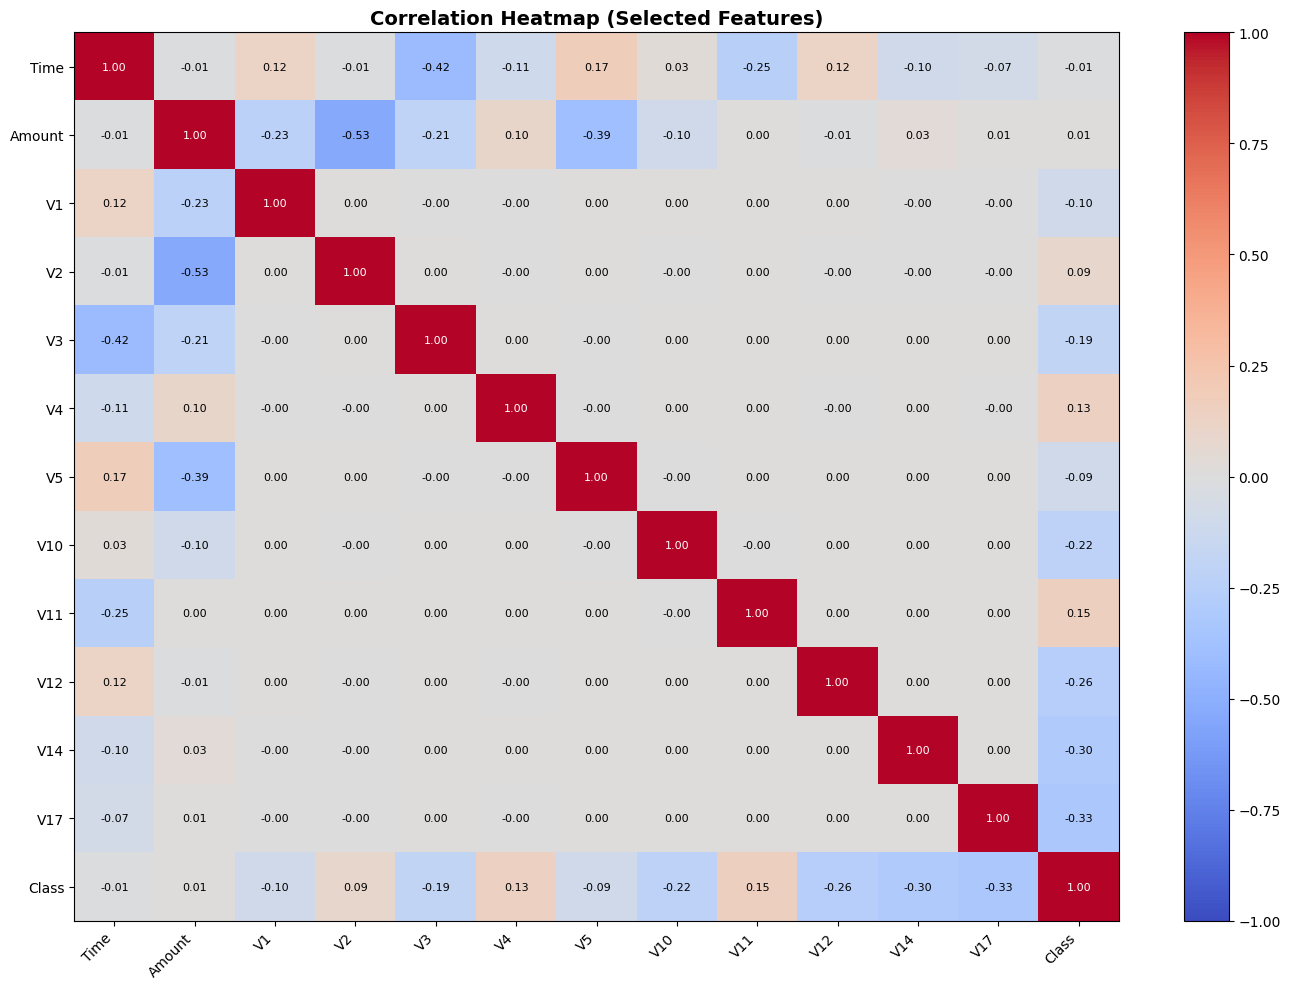

In [11]:
# --- 5.2 Correlation Heatmap ---
corr_cols   = ['Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V5',
                'V10', 'V11', 'V12', 'V14', 'V17', 'Class']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(val) < 0.6 else 'white')

ax.set_title('Correlation Heatmap (Selected Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

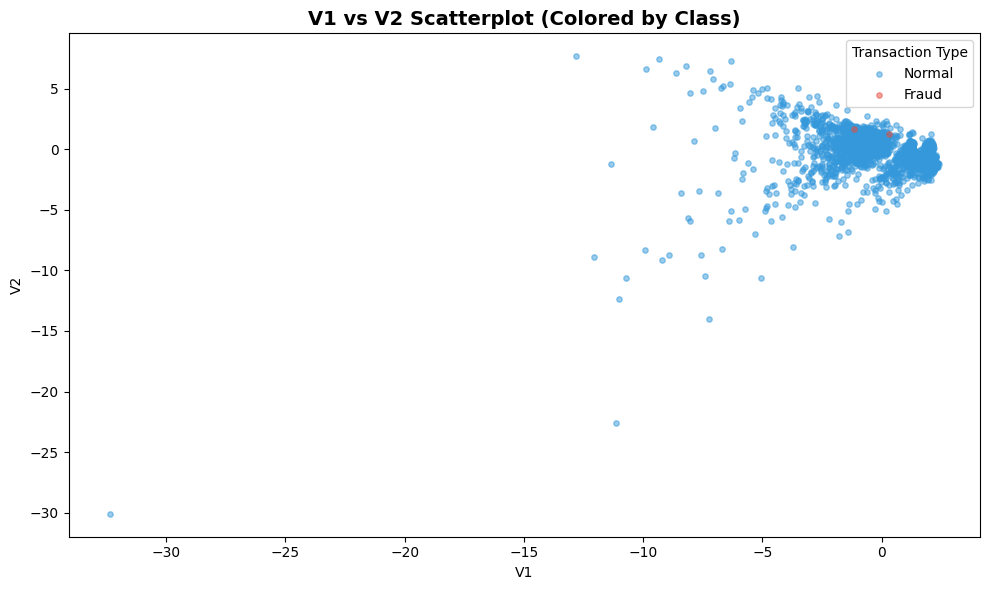

In [12]:
# --- 5.3 V1 vs V2 Scatterplot ---
sample_df2 = df.sample(3000, random_state=0)

plt.figure(figsize=(10, 6))
for cls, label, color in zip([0, 1], ['Normal', 'Fraud'], ['#3498db', '#e74c3c']):
    sub = sample_df2[sample_df2['Class'] == cls]
    plt.scatter(sub['V1'], sub['V2'], alpha=0.5, label=label, color=color, s=15)

plt.title('V1 vs V2 Scatterplot (Colored by Class)', fontsize=14, fontweight='bold')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.show()

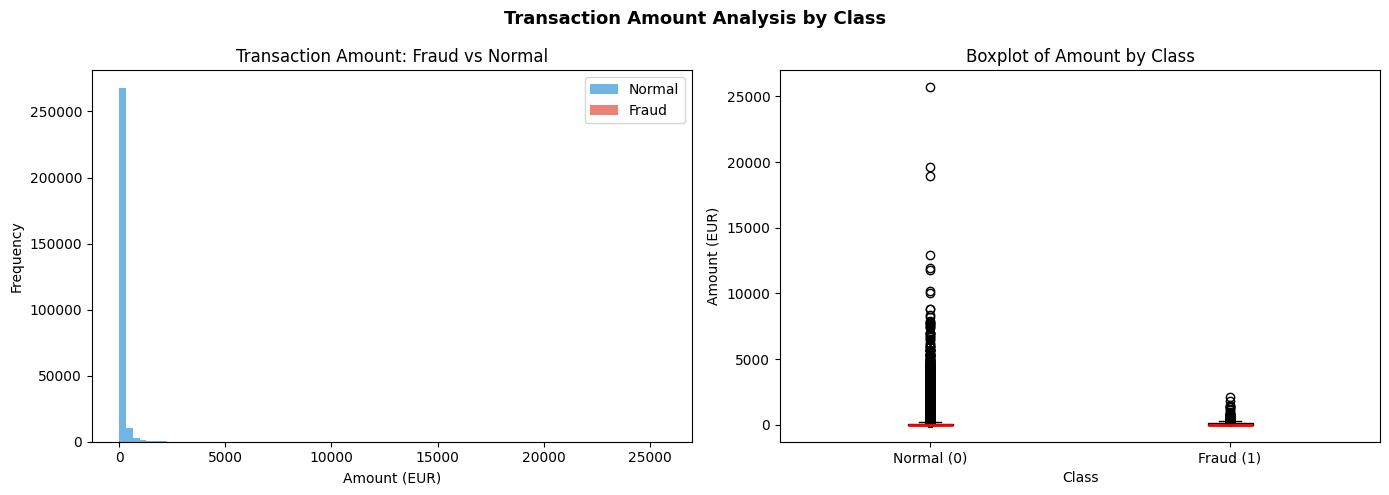

Average Amount  —  Normal: EUR 88.29  |  Fraud: EUR 122.21


In [13]:
# --- 5.4 Amount by Class Boxplot and Histogram ---
fraud  = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal, bins=80, color='#3498db', alpha=0.7, label='Normal')
axes[0].hist(fraud,  bins=80, color='#e74c3c', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount: Fraud vs Normal')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot([normal, fraud], labels=['Normal (0)', 'Fraud (1)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot of Amount by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Amount (EUR)')

plt.suptitle('Transaction Amount Analysis by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Average Amount  —  Normal: EUR {normal.mean():.2f}  |  Fraud: EUR {fraud.mean():.2f}')

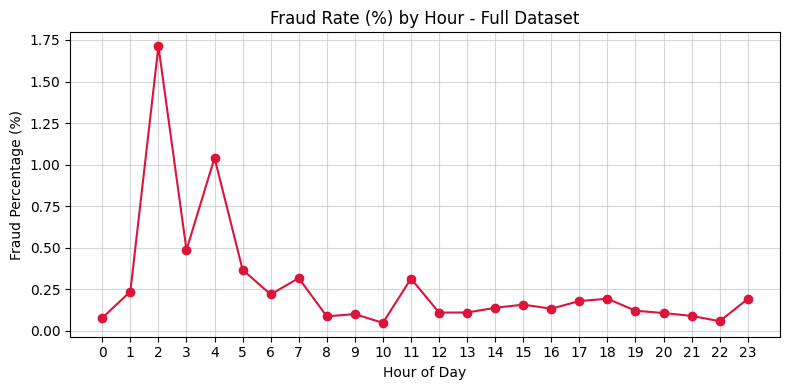

Highest fraud rate: 1.71% occurs at hour(s): [2.0]


In [14]:
# 5.5 Fraud Rate % per Hour 
df['Hour'] = (df['Time'] // 3600) % 24  # Convert seconds to 24-hour format
fraud_rate_full = df.groupby('Hour')['Class'].mean() * 100  # Percentage of fraud per hour

# Plot
plt.figure(figsize=(8, 4))
fraud_rate_full.plot(marker='o', color='crimson')
plt.title("Fraud Rate (%) by Hour - Full Dataset")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage (%)")
plt.grid(alpha=0.5)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# Print highest fraud hour(s)
max_rate = fraud_rate_full.max()
hours_max = fraud_rate_full[fraud_rate_full == max_rate].index.tolist()
print(f"Highest fraud rate: {max_rate:.2f}% occurs at hour(s): {hours_max}")

=== Missing Values ===
        Missing Count  Missing %
Time                0        0.0
V1                  0        0.0
V2                  0        0.0
V3                  0        0.0
V4                  0        0.0
V5                  0        0.0
V6                  0        0.0
V7                  0        0.0
V8                  0        0.0
V9                  0        0.0
V10                 0        0.0
V11                 0        0.0
V12                 0        0.0
V13                 0        0.0
V14                 0        0.0
V15                 0        0.0
V16                 0        0.0
V17                 0        0.0
V18                 0        0.0
V19                 0        0.0
V20                 0        0.0
V21                 0        0.0
V22                 0        0.0
V23                 0        0.0
V24                 0        0.0
V25                 0        0.0
V26                 0        0.0
V27                 0        0.0
V28                 

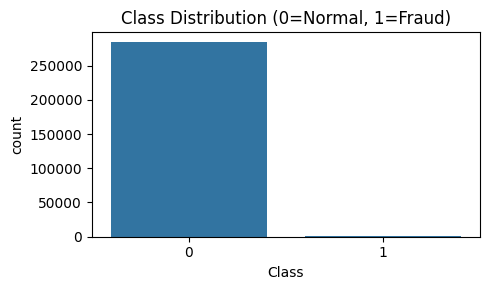

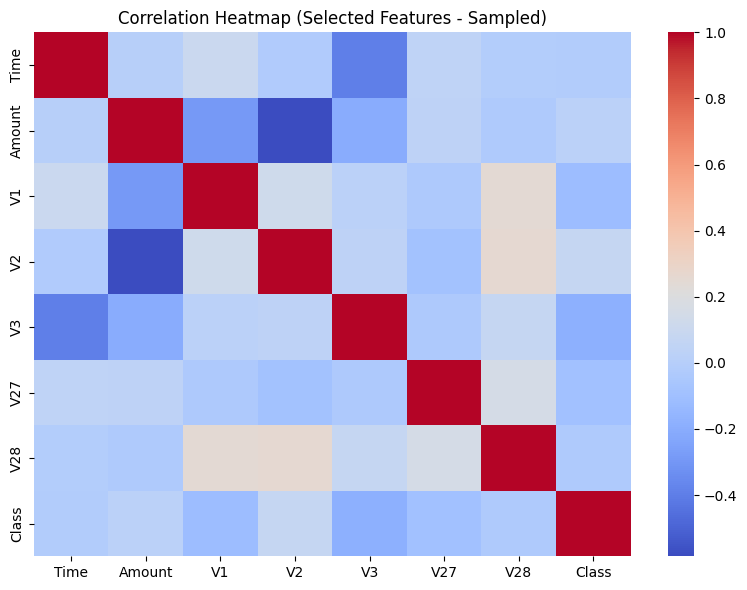


=== Interpretation ===
✔ No missing values found → dataset is complete and reliable
✔ Some duplicate rows exist → may introduce bias if not handled
✔ Dataset is highly imbalanced → fraud cases are very rare
✔ No invalid negative transaction amounts
✔ Class labels are valid (only 0 and 1)

 Section 6 Completed Successfully!


In [15]:

# Section 6: Data Quality Assessment 


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')


# Load Dataset

df = pd.read_csv("creditcard.csv")

# 1 Missing Values

missing_count   = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_percent.round(2)
})

print("=== Missing Values ===")
print(missing_df)
print(f"\nTotal missing values: {missing_count.sum()}")


# 2 Duplicate Rows

duplicate_count   = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("\n=== Duplicate Rows ===")
print(f"Total Duplicates : {duplicate_count}")
print(f"Percentage       : {duplicate_percent:.4f}%")

# Breakdown by class
dup_class = df[df.duplicated(keep=False)]['Class'].value_counts()

print("\nDuplicates by Class:")
print(f"  Legitimate (0) : {dup_class.get(0, 0)}")
print(f"  Fraudulent (1) : {dup_class.get(1, 0)}")


# 3 Unusual Values Check

neg_amount    = df[df['Amount'] < 0].shape[0]
zero_amount   = df[df['Amount'] == 0].shape[0]
invalid_class = df[~df['Class'].isin([0, 1])].shape[0]

print("\n=== Unusual Values ===")
print(f"Negative Amount Transactions : {neg_amount}")
print(f"Zero Amount Transactions     : {zero_amount}")
print(f"Invalid Class Values         : {invalid_class}")


# 4️ Class Imbalance
class_counts = df['Class'].value_counts()

#  Safe version (no error risk)
fraud_ratio = (class_counts.get(1, 0) / len(df)) * 100

print("\n=== Class Distribution ===")
print(class_counts)
print(f"Fraud Ratio: {fraud_ratio:.4f}%")

plt.figure(figsize=(5, 3))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0=Normal, 1=Fraud)")
plt.tight_layout()
plt.show()

# 5️ Correlation Heatmap (Optimized)
sample = df.sample(3000, random_state=42)

cols = ['Time', 'Amount', 'V1', 'V2', 'V3', 'V27', 'V28', 'Class']

plt.figure(figsize=(8, 6))
sns.heatmap(sample[cols].corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap (Selected Features - Sampled)")
plt.tight_layout()
plt.show()


# 6️ Interpretation

print("\n=== Interpretation ===")

if missing_count.sum() == 0:
    print("✔ No missing values found → dataset is complete and reliable")

if duplicate_count > 0:
    print("✔ Some duplicate rows exist → may introduce bias if not handled")

if fraud_ratio < 1:
    print("✔ Dataset is highly imbalanced → fraud cases are very rare")

if neg_amount == 0:
    print("✔ No invalid negative transaction amounts")

if invalid_class == 0:
    print("✔ Class labels are valid (only 0 and 1)")


# 🔥 CLEANUP

del sample
gc.collect()
plt.close('all')

print("\n Section 6 Completed Successfully!")

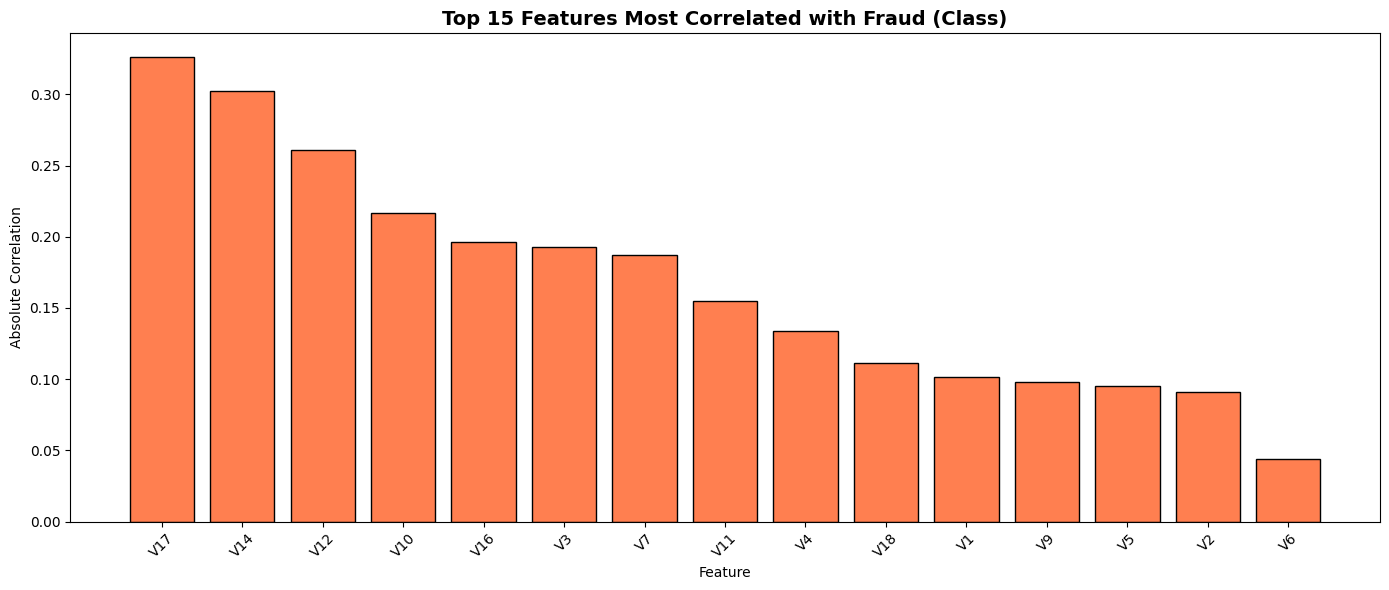

Top 10 Features Correlated with Fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [16]:
# --- section 7: Top Features Correlated with Fraud ---
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('creditcard.csv')

# Compute absolute correlation with Class
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

# Select top 15 features
top15 = corr_with_class.head(15)

# Bar Plot
plt.figure(figsize=(14, 6))
plt.bar(top15.index, top15.values, color='coral', edgecolor='black')
plt.title('Top 15 Features Most Correlated with Fraud (Class)',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print top 10 features
print('Top 10 Features Correlated with Fraud:')
print(corr_with_class.head(10).to_string())

Dataset Shape: (284807, 31)


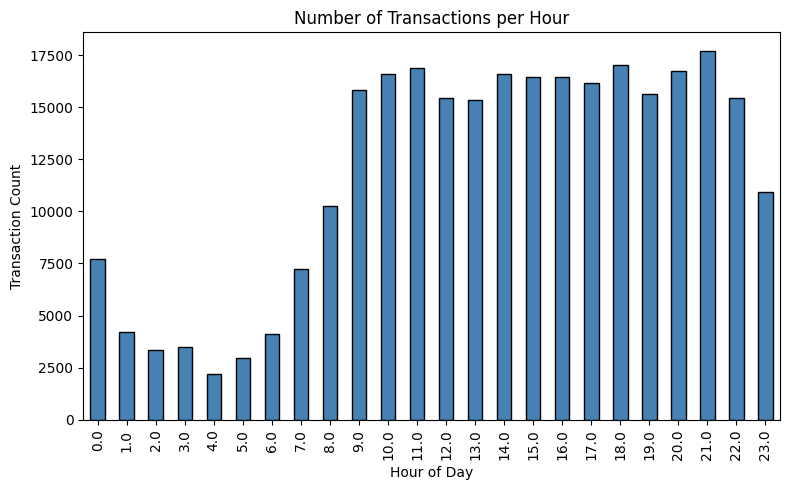


Top Transaction Hours:
Hour
21.0    17703
18.0    17039
11.0    16856
20.0    16756
10.0    16598
Name: Amount, dtype: int64

✔ Linear Regression Model Trained Successfully

Sample Predictions:
Actual: 30.3492 | Predicted: 38.0944
Actual: 40.0092 | Predicted: 51.6346
Actual: 3.1000 | Predicted: 9.0030
Actual: 0.0652 | Predicted: -8.8619
Actual: 0.0387 | Predicted: -8.9194


In [17]:
# =========================================================
# CREDIT CARD ANALYSIS - LINEAR REGRESSION (SIMPLIFIED)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# -------------------- LOAD DATASET --------------------
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

# -------------------- FEATURE ENGINEERING --------------------
df['Hour'] = (df['Time'] // 3600) % 24
df['AmountPerHour'] = df['Amount'] / (df['Hour'] + 1)

# =========================================================
# 1️⃣ DATA INSIGHT: PEAK TRANSACTION HOURS
# =========================================================

hour_counts = df.groupby("Hour")["Amount"].count()

plt.figure(figsize=(8,5))
hour_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Number of Transactions per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

print("\nTop Transaction Hours:")
print(hour_counts.sort_values(ascending=False).head(5))

# =========================================================
# 2️⃣ LINEAR REGRESSION (MATRIX FORM)
# =========================================================

# Features (inputs)
X = df[['Hour', 'Amount']].values

# Target (output)
y = df['AmountPerHour'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias column (for intercept)
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Normal Equation (Linear Regression)
beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# Predictions
y_train_pred = X_train_b @ beta
y_test_pred  = X_test_b @ beta

print("\n✔ Linear Regression Model Trained Successfully")

# Show sample predictions only
print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {y_test[i]:.4f} | Predicted: {y_test_pred[i]:.4f}")

Original Dataset Shape: (284807, 31)

--- WITH DUPLICATES ---
Train RMSE: 32.873492024838
Test RMSE : 28.514831497750674
R2 Score  : 0.37240988614178594

--- WITHOUT DUPLICATES ---
Train RMSE: 32.82453284008066
Test RMSE : 29.039046289797245
R2 Score  : 0.3867781660767229

--- WITH OUTLIERS ---
Train RMSE: 32.873492024838
Test RMSE : 28.514831497750674
R2 Score  : 0.37240988614178594

--- WITHOUT OUTLIERS ---
Train RMSE: 7.455138646384178
Test RMSE : 7.7592168304199465
R2 Score  : 0.3233658948551523

================ FINAL TABLE ================
            Condition  Train RMSE  Test RMSE  R2 Score
0     With Duplicates   32.873492  28.514831  0.372410
1  Without Duplicates   32.824533  29.039046  0.386778
2       With Outliers   32.873492  28.514831  0.372410
3    Without Outliers    7.455139   7.759217  0.323366


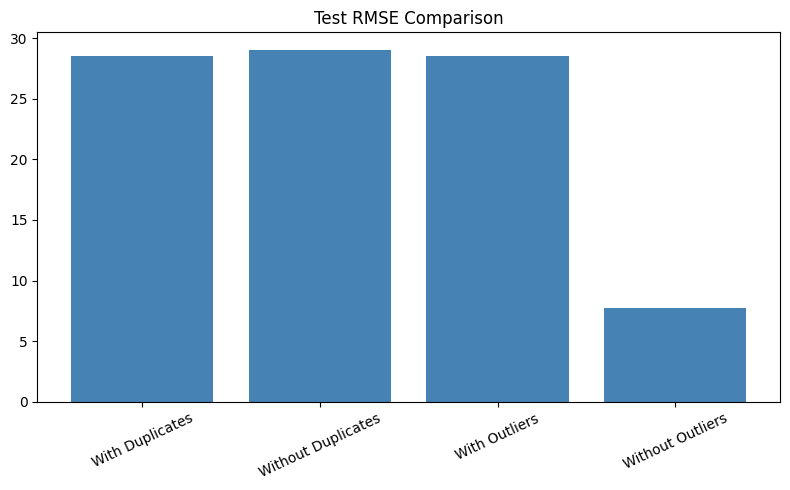

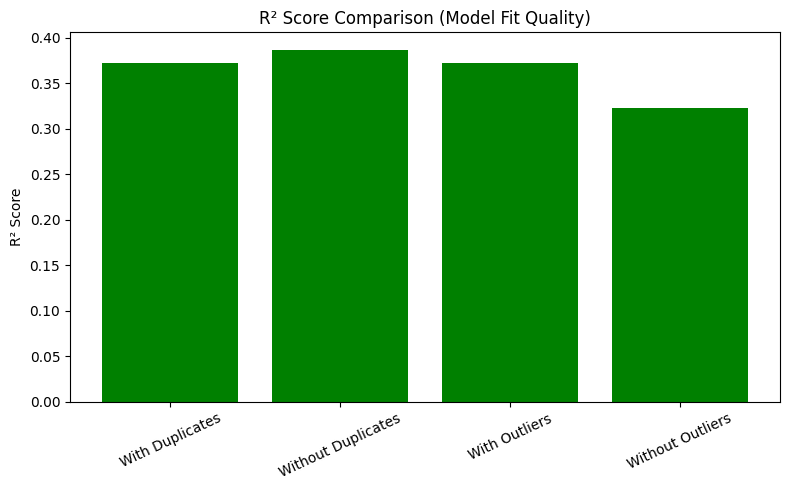

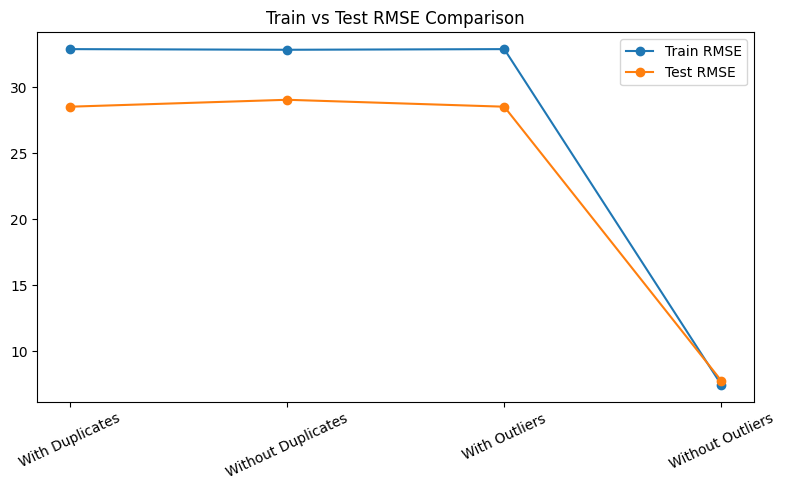


DONE ✔ Project Completed


In [18]:
# =========================================================
# CREDIT CARD ANALYSIS - LINEAR REGRESSION + TIME INSIGHT
# WITH RMSE + R² COMPARISON VISUALIZATION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -------------------- LOAD DATASET --------------------
df = pd.read_csv("creditcard.csv")
print("Original Dataset Shape:", df.shape)

# -------------------- FEATURE ENGINEERING --------------------
df['Hour'] = (df['Time'] // 3600) % 24
df['AmountPerHour'] = df['Amount'] / (df['Hour'] + 1)

# =========================================================
# OUTLIER FUNCTION
# =========================================================
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[col] >= lower) & (data[col] <= upper)]

# =========================================================
# LINEAR REGRESSION FUNCTION
# =========================================================
def run_model(data, label):

    X = data[['Hour', 'Amount']].values
    y = data['AmountPerHour'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # matrix form
    X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

    # normal equation
    beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

    # predictions
    y_train_pred = X_train_b @ beta
    y_test_pred  = X_test_b @ beta

    # metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)

    print("\n---", label, "---")
    print("Train RMSE:", train_rmse)
    print("Test RMSE :", test_rmse)
    print("R2 Score  :", r2)

    return train_rmse, test_rmse, r2

# =========================================================
# MODELS
# =========================================================
tr1, te1, r21 = run_model(df.copy(), "WITH DUPLICATES")

df_no_dup = df.drop_duplicates()
tr2, te2, r22 = run_model(df_no_dup, "WITHOUT DUPLICATES")

df_out = remove_outliers(df, 'Amount')
df_out = remove_outliers(df_out, 'Hour')

tr3, te3, r23 = run_model(df.copy(), "WITH OUTLIERS")
tr4, te4, r24 = run_model(df_out, "WITHOUT OUTLIERS")

# =========================================================
# FINAL TABLE
# =========================================================
results = pd.DataFrame({
    "Condition": [
        "With Duplicates",
        "Without Duplicates",
        "With Outliers",
        "Without Outliers"
    ],
    "Train RMSE": [tr1, tr2, tr3, tr4],
    "Test RMSE":  [te1, te2, te3, te4],
    "R2 Score":   [r21, r22, r23, r24]
})

print("\n================ FINAL TABLE ================")
print(results)

# =========================================================
# RMSE PLOT
# =========================================================
plt.figure(figsize=(8,5))
plt.bar(results['Condition'], results['Test RMSE'], color='steelblue')
plt.title("Test RMSE Comparison")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================================================
# 🔥 R² PLOT (NEW ADDITION)
# =========================================================
plt.figure(figsize=(8,5))
plt.bar(results['Condition'], results['R2 Score'], color='green')
plt.title("R² Score Comparison (Model Fit Quality)")
plt.ylabel("R² Score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================================================
# TRAIN vs TEST RMSE
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(results['Condition'], results['Train RMSE'], marker='o', label='Train RMSE')
plt.plot(results['Condition'], results['Test RMSE'], marker='o', label='Test RMSE')
plt.title("Train vs Test RMSE Comparison")
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print("\nDONE ✔ Project Completed")

Dataset Shape: (284807, 31)


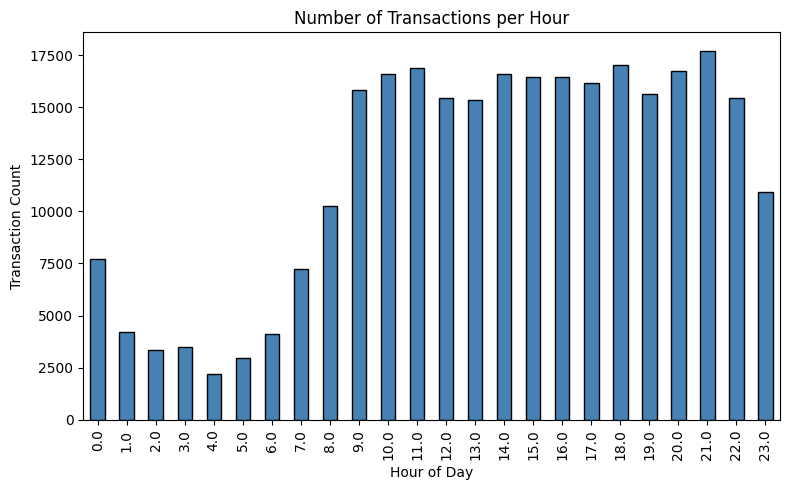


Top Transaction Hours:
Hour
21.0    17703
18.0    17039
11.0    16856
20.0    16756
10.0    16598
Name: Amount, dtype: int64

================ FINAL REGRESSION EQUATION ================
AmountPerHour = 
16.5295 + (-1.1608 * Hour) + (0.0943 * Amount) + (-0.0478 * V17)

✔ Linear Regression Model Built Successfully


In [19]:
# =========================================================
# CREDIT CARD ANALYSIS — MULTIPLE LINEAR REGRESSION
# Predicting AmountPerHour using Hour, Amount, V17
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# -------------------- LOAD DATASET --------------------
df = pd.read_csv("creditcard.csv")
print("Dataset Shape:", df.shape)

# -------------------- FEATURE ENGINEERING --------------------
df['Hour'] = (df['Time'] // 3600) % 24
df['AmountPerHour'] = df['Amount'] / (df['Hour'] + 1)

# =========================================================
# DATA INSIGHT — PEAK TRANSACTION HOURS
# =========================================================
hour_counts = df.groupby("Hour")["Amount"].count()

plt.figure(figsize=(8,5))
hour_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Number of Transactions per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

print("\nTop Transaction Hours:")
print(hour_counts.sort_values(ascending=False).head(5))

# =========================================================
# MULTIPLE LINEAR REGRESSION (MATRIX METHOD)
# =========================================================

# Features (inputs)
X = df[['Hour','Amount','V17']].values

# Target (output)
y = df['AmountPerHour'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias column (for β0)
X_train_b = np.hstack([np.ones((X_train.shape[0],1)), X_train])

# NORMAL EQUATION → β = (XᵀX)^(-1) Xᵀy
beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# =========================================================
# PRINT FINAL REGRESSION EQUATION
# =========================================================
b0, b1, b2, b3 = beta

print("\n================ FINAL REGRESSION EQUATION ================")
print("AmountPerHour = ")
print(f"{b0:.4f} + ({b1:.4f} * Hour) + ({b2:.4f} * Amount) + ({b3:.4f} * V17)")

print("\n✔ Linear Regression Model Built Successfully")